In [1]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [23]:
import re
import pandas as pd
from pathlib import Path

log_dir = Path("../slurm_outs")

records = []

for f in log_dir.glob("*.out"):

    txt = open(f).read()

    # correlation
    corr_match = re.search(r"Final correlation:\s*([0-9.]+)", txt)
    if not corr_match:
        continue

    corr = float(corr_match.group(1))

    # seed
    seed_match = re.search(r"Running seed\s*(\d+)", txt)
    seed = int(seed_match.group(1)) if seed_match else None

    # parse slurm job id
    m = re.search(r"slurm-(\d+)_?(\d+)?", f.name)
    job = int(m.group(1))
    idx = int(m.group(2)) if m.group(2) else 0

    depth = None
    width = None
    frac = None

    # ---- decode experiment type ----

    if job == 16527818:   # depth ablation
        depth = idx // 7

    elif job == 16528003: # width ablation
        widths = [512,1024,2048,4096]
        width = widths[idx // 7]

    elif job == 16528091: # fraction ablation
        fracs = [0.1,0.25,0.5,0.75,1.0]
        frac = fracs[idx // 7]

    records.append({
        "file": f.name,
        "seed": seed,
        "depth": depth,
        "width": width,
        "frac": frac,
        "corr": corr
    })

df = pd.DataFrame(records)

print("Runs parsed:", len(df))
df.head()

Runs parsed: 132


,file,seed,depth,width,frac,corr
0,slurm-16527488.out,NaN,NaN,NaN,NaN,0.2627
1,slurm-16527700_0.out,0.0,NaN,NaN,NaN,0.2627
2,slurm-16527700_1.out,1.0,NaN,NaN,NaN,0.2758
3,slurm-16527700_2.out,2.0,NaN,NaN,NaN,0.2761
4,slurm-16527700_3.out,3.0,NaN,NaN,NaN,0.2586


In [ ]:
depth_summary = (
    df[df.depth.notna()]
    .groupby("depth")
    .agg(mean_corr=("corr","mean"),
         std_corr=("corr","std"),
         n=("corr","count"))
    .reset_index()
)

depth_summary.head()


width_summary = (
    df[df.width.notna()]
    .groupby("width")
    .agg(mean_corr=("corr","mean"),
         std_corr=("corr","std"),
         n=("corr","count"))
    .reset_index()
)

width_summary.head()


frac_summary = (
    df[df.frac.notna()]
    .groupby("frac")
    .agg(mean_corr=("corr","mean"),
         std_corr=("corr","std"),
         n=("corr","count"))
    .reset_index()
)

frac_summary.head()

,depth,mean_corr,std_corr,n
0,0.0,0.287129,0.001754,7
1,1.0,0.282143,0.006619,7
2,2.0,0.269329,0.007755,7
3,3.0,0.273300,0.007345,7
4,4.0,0.273386,0.005000,7
5,5.0,0.273071,0.005936,7
6,6.0,0.268486,0.008514,7


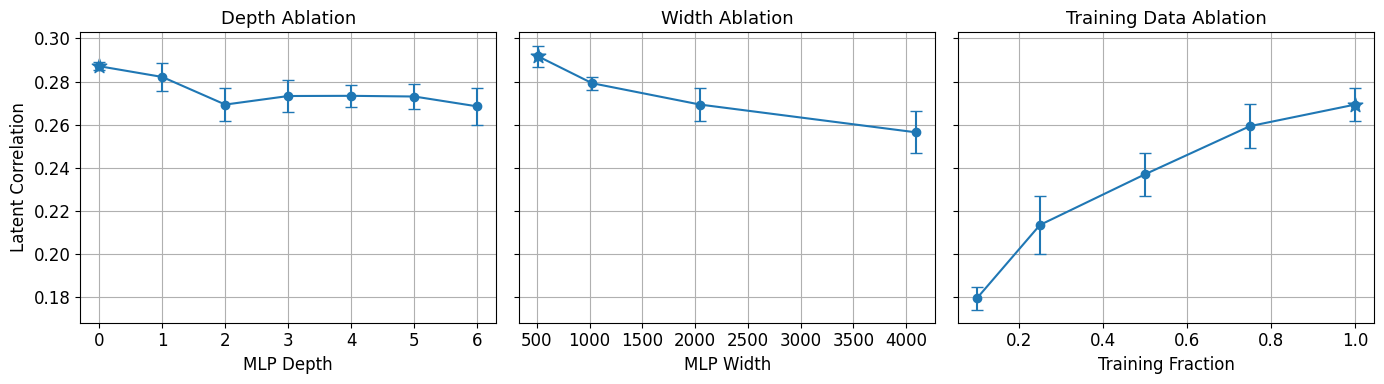

In [28]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12
})

fig, axes = plt.subplots(1,3,figsize=(14,4),sharey=True)

# Depth
axes[0].errorbar(
    depth_summary.depth,
    depth_summary.mean_corr,
    yerr=depth_summary.std_corr,
    marker="o",
    markersize=6,
    capsize=4
)
axes[0].scatter(
    depth_summary.loc[depth_summary.mean_corr.idxmax(),"depth"],
    depth_summary.mean_corr.max(),
    s=120,
    marker="*"
)
axes[0].set_title("Depth Ablation")
axes[0].set_xlabel("MLP Depth")
axes[0].set_ylabel("Latent Correlation")
axes[0].grid(True)

# Width
axes[1].errorbar(
    width_summary.width,
    width_summary.mean_corr,
    yerr=width_summary.std_corr,
    marker="o",
    markersize=6,
    capsize=4
)
axes[1].scatter(
    width_summary.loc[width_summary.mean_corr.idxmax(),"width"],
    width_summary.mean_corr.max(),
    s=120,
    marker="*"
)
axes[1].set_title("Width Ablation")
axes[1].set_xlabel("MLP Width")
axes[1].grid(True)

# Fraction
axes[2].errorbar(
    frac_summary.frac,
    frac_summary.mean_corr,
    yerr=frac_summary.std_corr,
    marker="o",
    markersize=6,
    capsize=4
)
axes[2].scatter(
    frac_summary.loc[frac_summary.mean_corr.idxmax(),"frac"],
    frac_summary.mean_corr.max(),
    s=120,
    marker="*"
)
axes[2].set_title("Training Data Ablation")
axes[2].set_xlabel("Training Fraction")
axes[2].grid(True)

plt.tight_layout()
plt.savefig("mlp_ablation_cvpr.png",dpi=300,bbox_inches="tight")
plt.show()

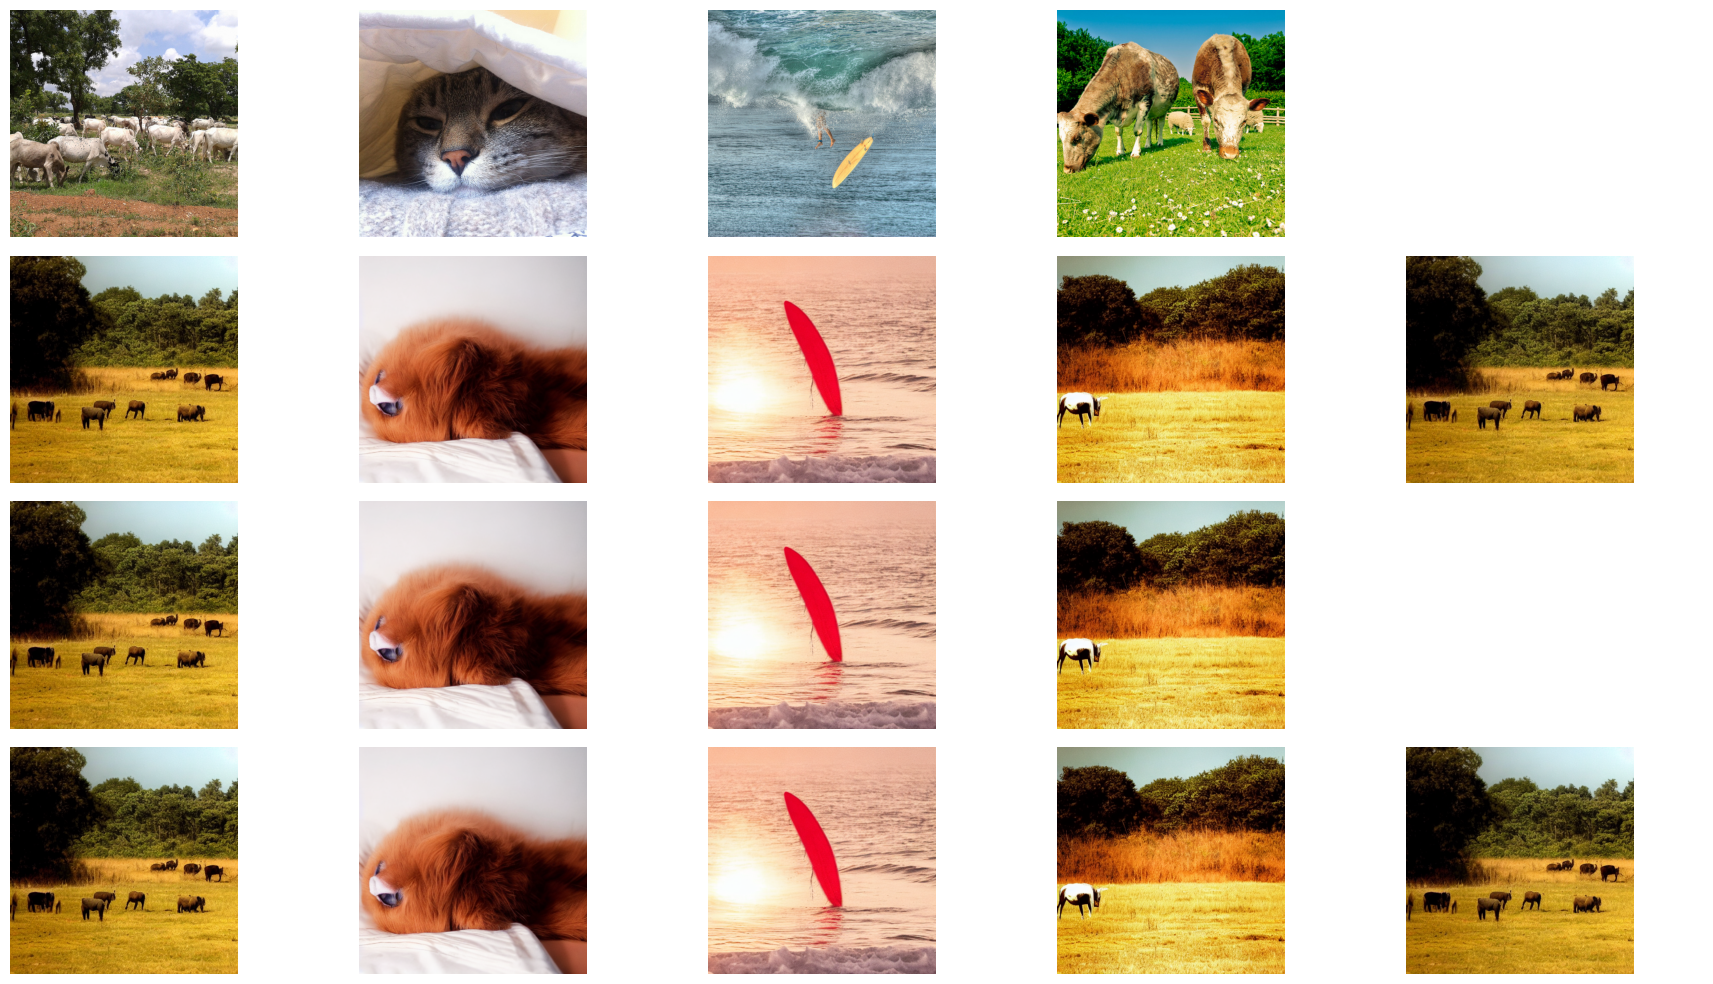

In [35]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

root = Path("../decoded")

# images to visualize
imgs = [0,240,480,720]

depth_methods = [
"mlp_seed0_d0_w2048_frac1.0",
"mlp_seed0_d1_w2048_frac1.0",
"mlp_seed0_d2_w2048_frac1.0",
"mlp_seed0_d4_w2048_frac1.0",
"mlp_seed0_d6_w2048_frac1.0"
]

width_methods = [
"mlp_seed0_d2_w512_frac1.0",
"mlp_seed0_d2_w1024_frac1.0",
"mlp_seed0_d2_w2048_frac1.0",
"mlp_seed0_d2_w4096_frac1.0"
]

data_methods = [
"mlp_seed0_d2_w2048_frac0.1",
"mlp_seed0_d2_w2048_frac0.25",
"mlp_seed0_d2_w2048_frac0.5",
"mlp_seed0_d2_w2048_frac0.75",
"mlp_seed0_d2_w2048_frac1.0"
]

panels = [depth_methods, width_methods, data_methods]
titles = ["Depth Ablation","Width Ablation","Data Ablation"]

max_cols = max(len(p) for p in panels)

fig,ax = plt.subplots(len(panels)+1, max_cols, figsize=(18,10))

# ----- Ground truth row -----
for c,imgid in enumerate(imgs):
    path = root / f"image-mlp_seed0_d2_w2048_frac1.0/subj01/samples/{imgid:05}_org.png"
    ax[0,c].imshow(mpimg.imread(path))
    ax[0,c].axis("off")

for c in range(len(imgs),max_cols):
    ax[0,c].axis("off")

ax[0,0].set_ylabel("Ground Truth",fontsize=16)

# ----- Ablation rows -----
for r,methods in enumerate(panels):

    for c,method in enumerate(methods):

        imgid = imgs[c % len(imgs)]   # cycle through images safely

        path = root / f"image-{method}/subj01/samples/{imgid:05}_000.png"

        img = mpimg.imread(path)

        ax[r+1,c].imshow(img)
        ax[r+1,c].axis("off")

    for c in range(len(methods),max_cols):
        ax[r+1,c].axis("off")

    ax[r+1,0].set_ylabel(titles[r],fontsize=16)

plt.tight_layout()

plt.savefig("cvpr_ablation_figure.svg",bbox_inches="tight")
plt.show()